# v2 rebuilt correctly

v2 is v1 plus `in_nitro`: a binary flag for whether a pitch falls inside the
convex hull of the locations where that hitter produced his top 5% exit
velocities — an attempt to tell the model where *this* hitter does damage.

This is v2 **as designed**, with its defects corrected and nothing added — the
zone stays a binary convex hull at the top-5% threshold with a 60-BIP minimum,
and `in_nitro` goes to both action models. Two things are fixed:

| defect | fix |
|---|---|
| The hull was built from the **same season** it scored, so `in_nitro` partly encoded the outcome it predicted, and on held-out seasons it used the future. | Built from **prior seasons only**. |
| `add_nitro_zone` inner-merged on `batter`, so a hitter with no hull vanished from the data entirely. | Left join; no hull → `False`. |

Learner and hyperparameters are held at v1's, so the only thing changing
between the two rows below is the feature. (The learner turns out not to
matter either way: YoY R² 0.519 under XGBoost against 0.530 under LightGBM on
v1's feature set.)

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src import data as D, features as F, evaluate as E
from src.baselines import fit_v1, predict_chosen, V1_FEATURES

pd.set_option('display.width', 130); sns.set_theme(style='whitegrid')
PALETTE = ['#FFB000', '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#3D1EB2']
TRAIN = [2022, 2023, 2024]
V2_FEATURES = V1_FEATURES + ['in_nitro']
print(V2_FEATURES)

['plate_x_mid', 'plate_z_mid', 'count', 'in_nitro']


In [2]:
df = D.drop_pitchers_batting(D.load_seasons(range(2021, 2027), verbose=False))
rv = D.run_value_table(df, years=range(2021, 2025))
df = D.apply_run_value(df, rv, name='target').dropna(subset=['target', 'plate_x_mid', 'plate_z_mid'])
print(f'{len(df):,} rows')

4,186,695 rows


## Building the nitro zone without leakage

Each season's hulls come from seasons strictly before it, asserted in
`season_in_nitro()`. 2021 has no prior season and therefore cannot be scored,
so v2 covers 2022–2026 and four year-over-year pairs.

In [3]:
v2df, coverage = F.season_in_nitro(df)
print(f'rows {len(df):,} -> {len(v2df):,}  (2021 unavailable: {(df.season == 2021).sum():,})')
coverage.round(3)

rows 4,186,695 -> 3,496,877  (2021 unavailable: 689,818)


,prior_seasons,hulls,qualified,qualified_with_hull,coverage,in_nitro_rate
season,,,,,,
2022,2021-2021,472,435,345,0.793,0.145
2023,2021-2022,590,432,356,0.824,0.203
2024,2021-2023,696,425,372,0.875,0.231
2025,2021-2024,777,419,358,0.854,0.251
2026,2021-2025,872,423,359,0.849,0.261


Coverage runs 79–85% of qualified hitters, worst in 2022 whose only prior is
2021. The remaining 15–21% score `in_nitro = False` on every pitch — under v2's
inner merge they would have been deleted from the data entirely, which at this
scale is a large and non-random loss.

Note `in_nitro_rate` climbing from 0.145 to 0.261. Come back to that below.

## Fit and score

v1 is refit on the same 2022–2026 window so the delta is like-for-like. The
v1 row computed over the full 2021–2026 span covers a different set of seasons
and five year-over-year pairs instead of four, so it is not directly
comparable.

In [4]:
m2 = fit_v1(v2df[v2df.season.isin(TRAIN)], features=V2_FEATURES)
d2 = predict_chosen(v2df, m2)
r2 = E.harness(d2, m2, 'v2', train_seasons=TRAIN)

v1df = df[df.season.isin(v2df.season.unique())].copy()
m1 = fit_v1(v1df[v1df.season.isin(TRAIN)])
d1 = predict_chosen(v1df, m1)
r1 = E.harness(d1, m1, 'v1 (2022-26)', train_seasons=TRAIN)

pd.DataFrame([r1['summary'], r2['summary']]).set_index('variant').T

variant,v1 (2022-26),v2
chase | zone_swing,-0.856,-0.754
zone_swing | chase,0.614,0.476
split-half r,0.753,0.786
YoY R2 (mean),0.517,0.53
Zone% |r|,0.077,0.033
next-season r (partial),0.095,0.105
take RMSE vs count-only,0.0429 / 0.0768,0.0430 / 0.0768
swing RMSE vs count-only,0.2974 / 0.2998,0.2973 / 0.2998


In [5]:
# Year over year, per consecutive pair.
pd.concat([r1['yoy'].r2.rename('v1'), r2['yoy'].r2.rename('v2')], axis=1).round(3)

,v1,v2
pair,,
2022->2023,0.576,0.566
2023->2024,0.557,0.561
2024->2025,0.507,0.517
2025->2026,0.428,0.474


## Player metric and reliability

Both variants side by side throughout. `E.harness()` computes each of these; the
summary row at the end reports their means, but the per-season detail is where
a difference either holds up across the board or turns out to rest on one
season.

In [6]:
qual = pd.concat([r1['scores'].groupby('season').size().rename('v1'),
                  r2['scores'].groupby('season').size().rename('v2')], axis=1)
print('qualified hitters (>=500 pitches) per season:')
qual

qualified hitters (>=500 pitches) per season:


,v1,v2
season,,
2022,435,435
2023,432,432
2024,425,425
2025,419,419
2026,423,423


In [7]:
# Split-half: odd/even plate appearances within a season, Spearman-Brown
# corrected. Cleaner than year-over-year, since real skill change is held fixed.
pd.concat([r1['split_half'].r_spearman_brown.rename('v1'),
           r2['split_half'].r_spearman_brown.rename('v2')], axis=1).round(3)

,v1,v2
season,,
2022,0.766,0.791
2023,0.799,0.827
2024,0.723,0.758
2025,0.761,0.802
2026,0.715,0.756


## Validity

Reliability only says the metric is repeatable. These two ask whether it is
repeatable *about the right thing*: not contaminated by the pitches a hitter
happened to see, and carrying information about what he does next.

In [8]:
# Zone%: does the metric mostly track the share of pitches a hitter sees in the
# strike zone? A metric explained by opportunity is not measuring decisions.
pd.concat([r1['zone_pct']['r'].rename('v1 r'),
           r2['zone_pct']['r'].rename('v2 r'),
           r1['zone_pct']['variance_explained_%'].rename('v1 var%'),
           r2['zone_pct']['variance_explained_%'].rename('v2 var%')], axis=1).round(3)

,v1 r,v2 r,v1 var%,v2 var%
season,,,,
2022,0.102,0.041,1.031,0.167
2023,0.055,-0.001,0.298,0.000
2024,0.098,0.058,0.963,0.337
2025,0.023,-0.052,0.055,0.275
2026,0.109,0.012,1.196,0.013


In [9]:
# Does season-t decision value predict season-t+1 production, once season-t
# production is controlled for?
pd.concat([r1['predictive'].r_raw.rename('v1 raw'), r2['predictive'].r_raw.rename('v2 raw'),
           r1['predictive'].r_partial.rename('v1 partial'),
           r2['predictive'].r_partial.rename('v2 partial')], axis=1).round(3)

,v1 raw,v2 raw,v1 partial,v2 partial
pair,,,,
2022->2023,0.305,0.334,0.165,0.179
2023->2024,0.291,0.319,0.153,0.170
2024->2025,0.278,0.279,0.124,0.099
2025->2026,0.110,0.146,-0.063,-0.028


**The de-leaked hull helps on some measures and hurts on one.** It improves
reliability (split-half 0.786 vs 0.753, YoY R² 0.530 vs 0.517), reduces
pitch-mix contamination (Zone% |r| 0.033 vs 0.077) and slightly improves
next-season validity (0.105 vs 0.095). But **construct validity degrades**:
−0.754 / +0.476 against v1's −0.856 / +0.614.

That combination is the signature of a hitter-specific feature pulling the
score away from "did he decide well" and toward "is he a good hitter" — a
hitter with a favourable hot zone gets a higher `Q_swing`, and so a higher
score, independent of his judgement. It is why reliability and prediction rise
while the decision construct weakens.

So the leaking implementation was the reason the design fell out of favour, and
de-leaking it does make the feature usable. But "usable" is not "free".

The per-season detail says how solid the reliability gain is. Split-half
favours v2 in **all five seasons**, by a consistent 0.03–0.04, so it is real
rather than one good year. Predictive validity is weaker evidence: v2 wins
**three of four** pairs and loses 2024→2025 (0.099 against 0.124). Zone%
contamination is negligible for both, and v2's sign flips across seasons, which
at |r| < 0.06 is noise rather than a finding.

## But what is `in_nitro` actually measuring?

The gains below are implausible for a binary flag, and the RMSE it buys is
negligible. Both point the same way.

In [10]:
for name, booster in (('take', m2.take), ('swing', m2.swing)):
    imp = booster.get_score(importance_type='gain'); tot = sum(imp.values())
    print(f'{name:6s} ' + '  '.join(f'{k} {v/tot:.1%}' for k, v in sorted(imp.items(), key=lambda x: -x[1])))

take   in_nitro 80.7%  count 9.7%  plate_z_mid 5.2%  plate_x_mid 4.5%
swing  in_nitro 89.3%  count 5.8%  plate_z_mid 3.4%  plate_x_mid 1.5%


In [11]:
# Plan A4's check: contact quality cannot change what an umpire calls, so
# in_nitro should do nothing for the take model.
tr = v2df[v2df.season.isin(TRAIN)]
for feats, lbl in ((V1_FEATURES, 'without in_nitro'), (V2_FEATURES, 'with in_nitro')):
    s = E.rmse_vs_count_baseline(tr, fit_v1(tr, features=feats))
    print(f'  {lbl:18s} take {s.loc["take","rmse"]:.5f}   swing {s.loc["swing","rmse"]:.5f}')

  without in_nitro   take 0.04283   swing 0.29705


  with in_nitro      take 0.04298   swing 0.29697


In [12]:
v2z = D.add_zone_frame(v2df)
v2z['in_zone'] = D.in_rulebook_zone(v2z, ball_edge=True)
print(f'P(in_nitro | in zone)     = {v2z.loc[v2z.in_zone, "in_nitro"].mean():.3f}')
print(f'P(in_nitro | out of zone) = {v2z.loc[~v2z.in_zone, "in_nitro"].mean():.3f}')
print(f'correlation(in_nitro, in_zone) = {np.corrcoef(v2z.in_nitro, v2z.in_zone)[0,1]:.3f}')
print(f'share of in_nitro pitches that are in the zone = {v2z.loc[v2z.in_nitro, "in_zone"].mean():.3f}')

P(in_nitro | in zone)     = 0.456
P(in_nitro | out of zone) = 0.034
correlation(in_nitro, in_zone) = 0.507
share of in_nitro pitches that are in the zone = 0.912


In [13]:
# If in_nitro were purely location it would be constant across hitters within a
# location cell. How much does it actually vary between hitters?
g = v2z[v2z.season == 2026]
cell = g.assign(cx=pd.cut(g.plate_x_mid, np.arange(-1.2, 1.3, 0.3), labels=False),
                cz=pd.cut(g.plate_z_mid, np.arange(1.2, 4.2, 0.3), labels=False)).dropna(subset=['cx', 'cz'])
per = cell.groupby(['cx', 'cz', 'batter'], observed=True).in_nitro.mean()
spread = per.groupby(level=[0, 1]).agg(['mean', 'std', 'size']).query('size >= 100')
print(f'between-hitter std of in_nitro within a location cell: median {spread["std"].median():.3f}')
print(f'cell means range {spread["mean"].min():.2f} .. {spread["mean"].max():.2f}')

between-hitter std of in_nitro within a location cell: median 0.247
cell means range 0.00 .. 0.70


Text(0.5, 1.02, 'The nitro zone grows as prior history accumulates')

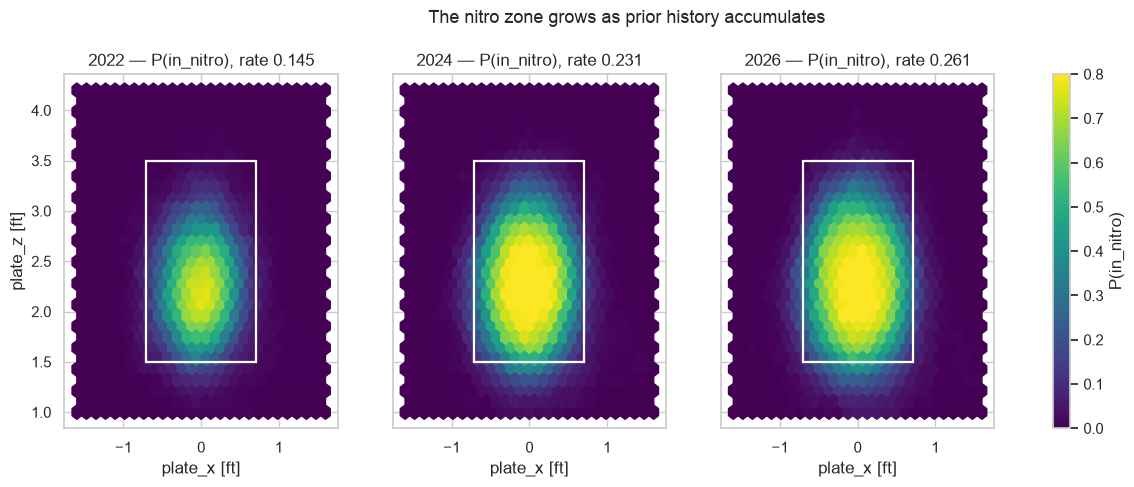

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for a, season in zip(ax, [2022, 2024, 2026]):
    g = v2z[v2z.season == season]
    hb = a.hexbin(g.plate_x_mid, g.plate_z_mid, C=g.in_nitro.astype(float), gridsize=26,
                  extent=[-1.6, 1.6, 1.0, 4.2], cmap='viridis', vmin=0, vmax=0.8)
    a.add_patch(plt.Rectangle((-0.708, 1.5), 1.416, 2.0, fill=False, color='w', lw=1.6))
    a.set_title(f'{season} — P(in_nitro), rate {g.in_nitro.mean():.3f}')
    a.set_xlabel('plate_x [ft]')
ax[0].set_ylabel('plate_z [ft]')
fig.colorbar(hb, ax=ax, label='P(in_nitro)')
fig.suptitle('The nitro zone grows as prior history accumulates', y=1.02, fontsize=13)

## Sanity check

In [15]:
scores2 = r2['scores']
try:
    from pybaseball import playerid_reverse_lookup
    s26 = scores2[scores2.season == 2026].copy()
    nm = playerid_reverse_lookup(s26.batter.tolist())
    nm['name'] = (nm.name_first + ' ' + nm.name_last).str.title()
    s26 = s26.merge(nm[['key_mlbam', 'name']], left_on='batter', right_on='key_mlbam')
    print('TOP 10, 2026'); display(s26.nlargest(10, 'decision_value')[['name','pitches','decision_value']].round(1))
    print('BOTTOM 10, 2026'); display(s26.nsmallest(10, 'decision_value')[['name','pitches','decision_value']].round(1))
except Exception as exc:
    print(f'name lookup unavailable ({exc})'); display(scores2[scores2.season == 2026].nlargest(10, 'decision_value'))

Gathering player lookup table. This may take a moment.


TOP 10, 2026


,name,pitches,decision_value
144,Juan Soto,1713,126.8
46,Corey Seager,1450,124.6
89,Gleyber Torres,1652,123.8
108,Ronald Acuña,1757,122.7
15,Bryce Harper,2557,121.5
248,Miguel Vargas,2613,121.2
121,Kyle Tucker,2334,120.3
288,Riley Greene,2303,118.8
170,Jj Bleday,2017,118.8
292,Anthony Volpe,868,118.4


BOTTOM 10, 2026


,name,pitches,decision_value
30,Javier Báez,623,70.5
342,Daniel Susac,590,73.6
369,Tommy White,612,73.9
33,Trevor Story,860,74.2
378,Jose Fernandez,798,74.8
279,Noelvi Marte,761,75.2
361,Abimelec Ortiz,530,75.4
229,Alika Williams,759,76.7
411,Colt Emerson,963,77.2
395,Brett Bateman,612,77.8


## Findings

**The de-leaked hull trades construct validity for reliability.** The feature
is not what made this design fail; the leak was. Built from prior seasons only,
holding learner and hyperparameters fixed, it raises split-half reliability in
all five seasons and next-season validity in three of four pairs, while cutting
pitch-mix contamination — but construct validity falls from −0.856 / +0.614 to
−0.754 / +0.476. A hitter-specific feature makes the score partly a measure of
the hitter rather than of his decisions. The gains are a few hundredths, so
this is a modest trade, not a breakthrough.

**But `in_nitro` is mostly a location proxy.** 91% of the pitches it flags are
in the strike zone, and it correlates 0.51 with zone membership. That is why it
takes 81–89% of the gain while changing RMSE in the fourth decimal: the tree
uses it as a cheap "middle of the zone" split, substituting for work
`plate_x_mid`/`plate_z_mid` were already doing. Gain here measures redundancy,
not contribution.

It is not *only* location — between-hitter standard deviation within a location
cell is 0.247, and cell means span 0.00 to 0.70 — so genuine personalization is
in there. It is just a small part of what the feature carries.

**It adds nothing to the take model, as predicted.** Take RMSE goes 0.04283 →
0.04298 when `in_nitro` is added: marginally *worse*, i.e. noise. Contact
quality cannot change what an umpire calls, and the data agrees. Routing it to
the swing model only is a change rather than a correction, so it belongs to the
patching work, but the evidence for doing it is now measured.

**The prior-season fix introduces drift.** Hull size scales with accumulated
history — median prior balls in play go 155 → 285 between 2022 and 2026, so the
top-5% set grows from ~7 points to ~14 and the flag fires on 14.5% of pitches in
2022 against 26.1% in 2026. The same hitter with the same true hot zone gets a
larger `in_nitro` region in later seasons. That is a real defect of the
correction itself and will need a fixed-window or fixed-area rule.

**Net:** v2 is now a usable baseline, and the personalization idea survives.
What the rebuild has to fix is the *estimator* — a binary hull over the top 5%
of one sample, drifting with history and largely redundant with location.

In [16]:
pd.DataFrame([r1['summary'], r2['summary']]).set_index('variant')

,chase | zone_swing,zone_swing | chase,split-half r,YoY R2 (mean),Zone% |r|,next-season r (partial),take RMSE vs count-only,swing RMSE vs count-only
variant,,,,,,,,
v1 (2022-26),-0.856,0.614,0.753,0.517,0.077,0.095,0.0429 / 0.0768,0.2974 / 0.2998
v2,-0.754,0.476,0.786,0.530,0.033,0.105,0.0430 / 0.0768,0.2973 / 0.2998
